In [39]:
## This Notebook is meant to be a sandbox for testing out the nfl_data_py library and exploring the data it provides. 
## It is not meant to be a polished analysis, but rather a place to experiment and learn how to use the library effectively.

import nfl_data_py as nfl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("All libraries imported successfully!")
print("Pandas version:", pd.__version__)

# Check for a local copy of the schedule data. If does not exist, create one
# This is a large file, so we want to avoid downloading it multiple times, and this should improve performance

if os.path.exists('.\data\schedules.csv'):
    print("Local copy of schedule data found. Loading from file...")
    schedules = pd.read_csv('.\data\schedules.csv')
else:
    schedules = nfl.import_schedules(list(range(1999, 2025)))
    os.makedirs('.\data', exist_ok=True)
    schedules.to_csv('.\data\schedules.csv', index=False)
    print("Schedules downloaded and saved locally")

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
C:\Users\johnt\AppData\Local\Temp\ipykernel_61324\241210827.py:17: SyntaxWarning: invalid escape sequence '\d'
  if os.path.exists('.\data\schedules.csv'):
C:\Users\johnt\AppData\Local\Temp\ipykernel_61324\241210827.py:19: SyntaxWarning: invalid escape sequence '\d'
  schedules = pd.read_csv('.\data\schedules.csv')
C:\Users\johnt\AppData\Local\Temp\ipykernel_61324\241210827.py:22: SyntaxWarning: invalid escape sequence '\d'
  os.makedirs('.\data', exist_ok=True)
C:\Users\johnt\AppData\Local\Temp\ipykernel_61324\241210827.py:23: SyntaxWarning: invalid escape sequence '\d'
  schedules.to

All libraries imported successfully!
Pandas version: 3.0.2
Schedules downloaded and saved locally


In [40]:
# Starting small with just the 2025 season to explore the data and get a feel for it
# Will do basic analysis to confirm with seperate source like PFR that outputs are correct

schedule = nfl.import_schedules([2025])

print(f"Rows: {schedule.shape[0]}, Columns: {schedule.shape[1]}")
schedule.head()

Rows: 285, Columns: 46


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
6991,2025_01_DAL_PHI,2025,REG,1,2025-09-04,Thursday,20:20,DAL,20,PHI,...,11.0,00-0033077,00-0036389,Dak Prescott,Jalen Hurts,Brian Schottenheimer,Nick Sirianni,Shawn Smith,PHI00,Lincoln Financial Field
6992,2025_01_KC_LAC,2025,REG,1,2025-09-05,Friday,20:00,KC,21,LAC,...,NaN,00-0033873,00-0036355,Patrick Mahomes,Justin Herbert,Andy Reid,Jim Harbaugh,Carl Cheffers,LAX01,SoFi Stadium
6993,2025_01_TB_ATL,2025,REG,1,2025-09-07,Sunday,13:00,TB,23,ATL,...,NaN,00-0034855,00-0039917,Baker Mayfield,Michael Penix,Todd Bowles,Raheem Morris,Land Clark,ATL97,Mercedes-Benz Stadium
6994,2025_01_CIN_CLE,2025,REG,1,2025-09-07,Sunday,13:00,CIN,17,CLE,...,10.0,00-0036442,00-0026158,Joe Burrow,Joe Flacco,Zac Taylor,Kevin Stefanski,Adrian Hill,CLE00,FirstEnergy Stadium
6995,2025_01_MIA_IND,2025,REG,1,2025-09-07,Sunday,13:00,MIA,8,IND,...,NaN,00-0036212,00-0035710,Tua Tagovailoa,Daniel Jones,Mike McDaniel,Shane Steichen,Brad Allen,IND00,Lucas Oil Stadium


In [41]:
print(schedule.columns.tolist())

['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium']


In [42]:

neededCols = [
    'game_id', 'season', 'game_type', 'week',
    'home_team', 'away_team',
    'home_score', 'away_score',
    'result', 'home_rest', 'away_rest',
    'div_game', 'location'
]

filteredSchedules = schedules[neededCols]

vikingsSchedule = filteredSchedules[(filteredSchedules['home_team'] == 'MIN') | (filteredSchedules['away_team'] == 'MIN')].copy()
print(f"Total Vikings Games: {len(vikingsSchedule)}")
print(vikingsSchedule.head())

Total Vikings Games: 437
            game_id  season game_type  week home_team away_team  home_score  \
0   1999_01_MIN_ATL    1999       REG     1       ATL       MIN          14   
23  1999_02_OAK_MIN    1999       REG     2       MIN       OAK          17   
33   1999_03_MIN_GB    1999       REG     3        GB       MIN          23   
50   1999_04_TB_MIN    1999       REG     4       MIN        TB          21   
65  1999_05_CHI_MIN    1999       REG     5       MIN       CHI          22   

    away_score  result  home_rest  away_rest  div_game location  
0           17      -3          7          7         0     Home  
23          22      -5          7          7         0     Home  
33          20       3          7          7         1     Home  
50          14       7          7          7         1     Home  
65          24      -2          7          7         1     Home  


In [43]:
# Tag when the Vikings have a bye week
# If the had_bye column is TRUE, then the Vikings had a bye week in the previous week
vikingsSchedule['had_bye'] = ((vikingsSchedule['home_team'] == 'MIN') & (vikingsSchedule['home_rest'] >= 14) |
 (vikingsSchedule['away_team'] == 'MIN') & (vikingsSchedule['away_rest'] >= 14))

#Check to see how many bye games we found
# For 2014 - 2025, we should expect to see 1 bye game per season, so 12 total bye games
print(f"Total Vikings Games with Bye Week: {vikingsSchedule['had_bye'].sum()}")
print(f"Total games without a bye week: {(~vikingsSchedule['had_bye']).sum()}")

Total Vikings Games with Bye Week: 28
Total games without a bye week: 409


In [44]:
vikingsSchedule[vikingsSchedule['had_bye'] == True].groupby('season')['had_bye'].count()

season
1999    1
2000    1
2001    2
2002    1
2003    1
2004    1
2005    1
2006    1
2007    1
2008    1
2009    2
2010    1
2011    1
2012    1
2013    1
2014    1
2015    1
2016    1
2017    2
2018    1
2019    1
2020    1
2021    1
2022    1
2024    1
Name: had_bye, dtype: int64

In [45]:
# There are some incorrect values in the bye week count. Adjusting rest day filter to 13, and also filtering for just the regular season
vikingsSchedule = filteredSchedules[((filteredSchedules['home_team'] == 'MIN') | (filteredSchedules['away_team'] == 'MIN')) & (filteredSchedules['game_type'] == 'REG')].copy()
vikingsSchedule['had_bye'] = ((vikingsSchedule['home_team'] == 'MIN') & (vikingsSchedule['home_rest'] >= 13) |
 (vikingsSchedule['away_team'] == 'MIN') & (vikingsSchedule['away_rest'] >= 13))

print(f"Total Vikings Games with Bye Week: {vikingsSchedule['had_bye'].sum()}")
print(f"Total games without a bye week: {(~vikingsSchedule['had_bye']).sum()}")
print("Bye Week count by season:")
print(vikingsSchedule[vikingsSchedule['had_bye'] == True].groupby('season')['had_bye'].count())

Total Vikings Games with Bye Week: 27
Total games without a bye week: 393
Bye Week count by season:
season
1999    1
2000    1
2001    2
2002    1
2003    1
2004    1
2005    1
2006    1
2007    1
2008    1
2009    1
2010    1
2011    1
2012    1
2013    1
2014    1
2015    1
2016    1
2017    1
2018    1
2019    1
2020    1
2021    1
2022    1
2023    1
2024    1
Name: had_bye, dtype: int64


In [46]:
# Add a column for whether the Vikings won the game or not
vikingsSchedule['vikings_win'] = ((vikingsSchedule['home_team'] == 'MIN') & (vikingsSchedule['result'] > 0)) | ((vikingsSchedule['away_team'] == 'MIN') & (vikingsSchedule['result'] < 0))
print(f"# of Vikings Wins: {vikingsSchedule['vikings_win'].sum()}")

# of Vikings Wins: 224


In [47]:
# First Question: How often do the Vikings win their first game back from a bye week?

# Find Total Games played, and total games won
totalGames = len(vikingsSchedule)
totalWins = vikingsSchedule['vikings_win'].sum()
overallWinPercentage = totalWins / totalGames if totalGames > 0 else 0
print(f"Total Vikings Games: {totalGames}")
print(f"Total Vikings Wins: {totalWins}")
print(f"Overall Vikings Win Percentage: {overallWinPercentage:.2%}")
print("-----------------------------------")

postByeGames = vikingsSchedule[vikingsSchedule['had_bye'] == True]
totalByeGames = len(postByeGames)
gamesWon = postByeGames['vikings_win'].sum()
winPercentage = postByeGames['vikings_win'].mean() if totalByeGames > 0 else 0
print(f"Total Games After Bye Week: {totalByeGames}")
print(f"Total Games Won After Bye Week: {gamesWon}")
print(f"Vikings Win Percentage After Bye Week: {winPercentage:.2%}")
print("-----------------------------------")

noneByeGames = vikingsSchedule[vikingsSchedule['had_bye'] == False]
totalNonByeGames = len(noneByeGames)
nonByeWins = noneByeGames['vikings_win'].sum()
nonByeWinPercentage = noneByeGames['vikings_win'].mean() if totalNonByeGames > 0 else 0
print(f"Total Games Without Bye Week: {totalNonByeGames}")
print(f"Total Games Won Without Bye Week: {nonByeWins}")
print(f"Vikings Win Percentage Without Bye Week: {nonByeWinPercentage:.2%}")

Total Vikings Games: 420
Total Vikings Wins: 224
Overall Vikings Win Percentage: 53.33%
-----------------------------------
Total Games After Bye Week: 27
Total Games Won After Bye Week: 14
Vikings Win Percentage After Bye Week: 51.85%
-----------------------------------
Total Games Without Bye Week: 393
Total Games Won Without Bye Week: 210
Vikings Win Percentage Without Bye Week: 53.44%


In [48]:
winRateData = pd.DataFrame({
    'Category': ["Overall Win Percentage", "Win Percentage After Bye Week", "Win Percentage Without Bye Week"],
    'Win Percentage': [overallWinPercentage, winPercentage, nonByeWinPercentage]
})

print(winRateData)

                          Category  Win Percentage
0           Overall Win Percentage        0.533333
1    Win Percentage After Bye Week        0.518519
2  Win Percentage Without Bye Week        0.534351


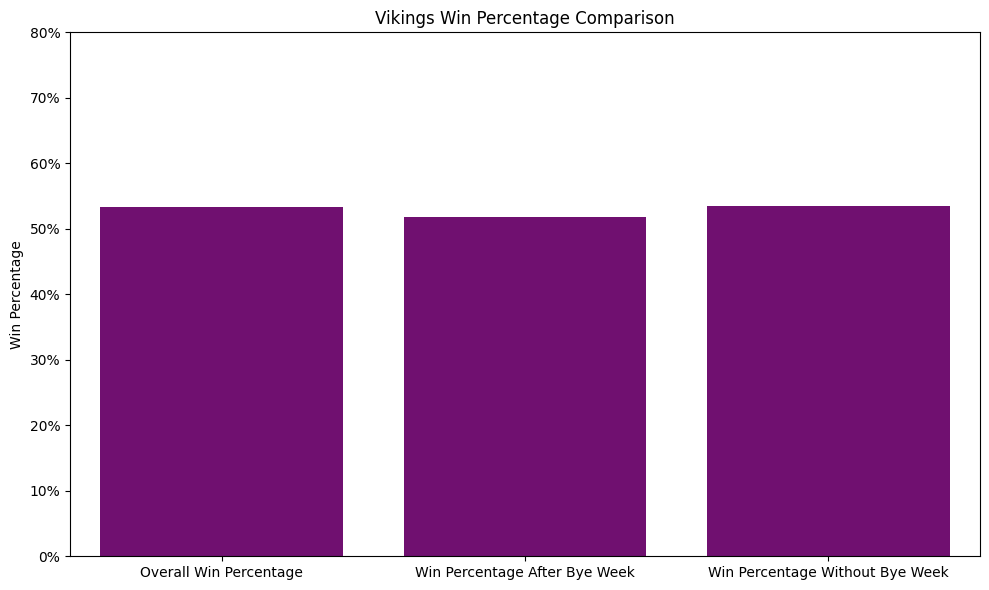

In [49]:
# Make a bar chart to compare the win percentages

# Initialize the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Win Percentage', data=winRateData, color='purple')

plt.title('Vikings Win Percentage Comparison')
plt.ylabel('Win Percentage')
plt.xlabel('')

# Format the Y-axis to show percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Properly scale the Y-axis to show from 0% to 80%
plt.ylim(0, 0.80)

# Show the plot
plt.tight_layout()
plt.show()

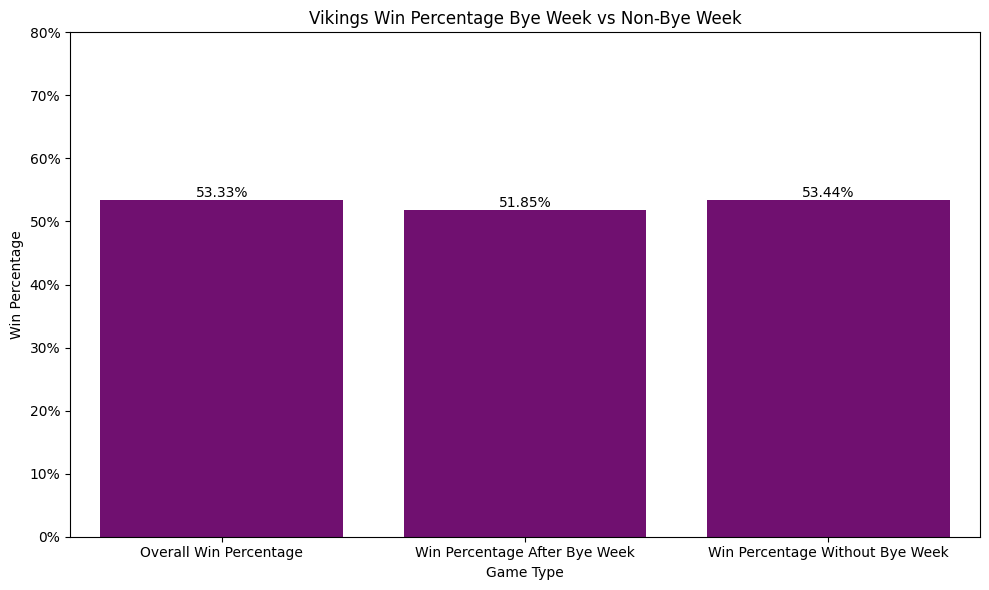

In [50]:
# Let's enhance the bar chart by adding the exact win percentage values on top of each bar for better clarity

# Initialize the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Category', y='Win Percentage', data=winRateData, color='purple')

plt.title('Vikings Win Percentage Bye Week vs Non-Bye Week')
plt.ylabel('Win Percentage')
plt.xlabel('Game Type')

# Add the percentage values on top of each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.2%}',
        ha='center',
        va='bottom'
    )

# Format the Y-axis to show percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Properly scale the Y-axis to show from 0% to 80%
plt.ylim(0, 0.80)

# Show the plot
plt.tight_layout()
plt.show()

In [51]:
# Begin point differential analysis

# Add a point differential column to the df
vikingsSchedule['differential'] = np.where(vikingsSchedule['home_team'] == 'MIN', vikingsSchedule['home_score'] - vikingsSchedule['away_score'],
                                                                                  vikingsSchedule['away_score'] - vikingsSchedule['home_score'])

vikingsSchedule.head()

,game_id,season,game_type,week,home_team,away_team,home_score,away_score,result,home_rest,away_rest,div_game,location,had_bye,vikings_win,differential
0,1999_01_MIN_ATL,1999,REG,1,ATL,MIN,14,17,-3,7,7,0,Home,False,True,3
23,1999_02_OAK_MIN,1999,REG,2,MIN,OAK,17,22,-5,7,7,0,Home,False,False,-5
33,1999_03_MIN_GB,1999,REG,3,GB,MIN,23,20,3,7,7,1,Home,False,False,-3
50,1999_04_TB_MIN,1999,REG,4,MIN,TB,21,14,7,7,7,1,Home,False,True,7
65,1999_05_CHI_MIN,1999,REG,5,MIN,CHI,22,24,-2,7,7,1,Home,False,False,-2


In [52]:
overallDifferential = vikingsSchedule['differential'].mean()
avgByeWeekDifferential = vikingsSchedule[vikingsSchedule['had_bye'] == True]['differential'].mean()
avgNonByeWeekDifferential = vikingsSchedule[vikingsSchedule['had_bye'] == False]['differential'].mean()

print(f"Overall Average Point Differential: {overallDifferential:.2f}")
print(f"Average Point Differential After Bye Week: {avgByeWeekDifferential:.2f}")
print(f"Average Point Differential Without Bye Week: {avgNonByeWeekDifferential:.2f}")

Overall Average Point Differential: 0.72
Average Point Differential After Bye Week: -2.89
Average Point Differential Without Bye Week: 0.97


In [53]:
# Begin Home/Away split analysis
# Do the Vikings win more games at home after the bye? Or away?

# Get the Home games after a bye
postByeHomeGames = vikingsSchedule[(vikingsSchedule['home_team'] == 'MIN') & (vikingsSchedule['had_bye'] == True)]
postByeWins = len(postByeHomeGames[postByeHomeGames['vikings_win'] == True])

print(f"Home Wins: {postByeWins} out of {len(postByeHomeGames)} games ({postByeWins / len(postByeHomeGames):.2%} win percentage)")

# Away Games
postByeAwayGames = vikingsSchedule[(vikingsSchedule['away_team'] == 'MIN') & (vikingsSchedule['had_bye'] == True)]
postByeAwayWins = len(postByeAwayGames[postByeAwayGames['vikings_win'] == True])
print(f"Away Wins: {postByeAwayWins} out of {len(postByeAwayGames)} games ({postByeAwayWins / len(postByeAwayGames):.2%})")

Home Wins: 7 out of 10 games (70.00% win percentage)
Away Wins: 7 out of 17 games (41.18%)


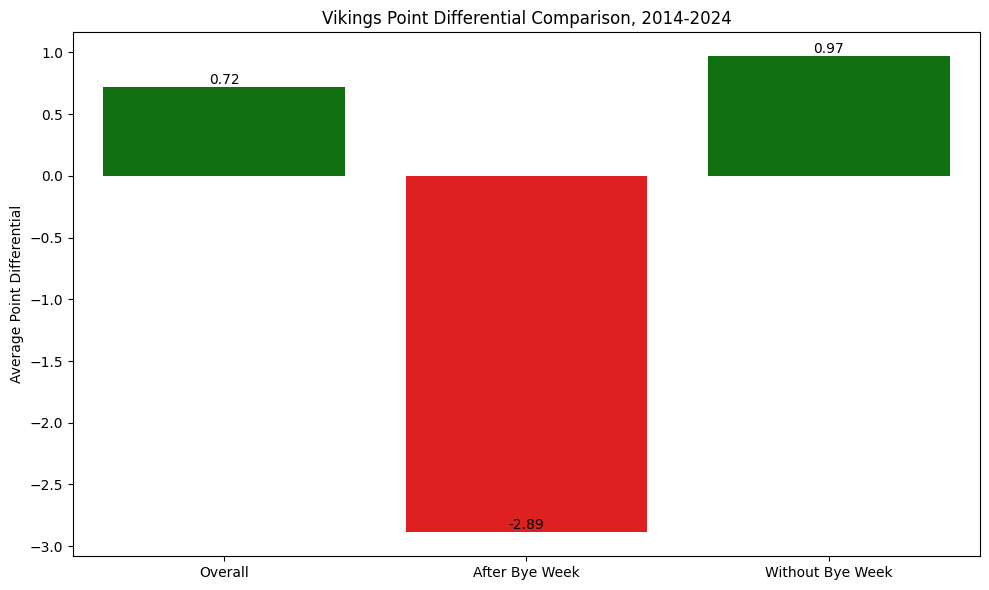

In [54]:
# Plot the differnetial on a bar chart
differentialData = pd.DataFrame({
    'Category': ["Overall", "After Bye Week", "Without Bye Week"],
    'Point Differential': [overallDifferential, avgByeWeekDifferential, avgNonByeWeekDifferential]
})

plt.figure(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in differentialData['Point Differential']]
ax = sns.barplot(x='Category', y='Point Differential', data=differentialData, hue='Category', palette=colors, legend=False)

# Set the labels
plt.title("Vikings Point Differential Comparison, 2014-2024")
plt.ylabel("Average Point Differential")
plt.xlabel("")

# If the differential is > 0, the bar is green, if < 0, the bar should be red
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

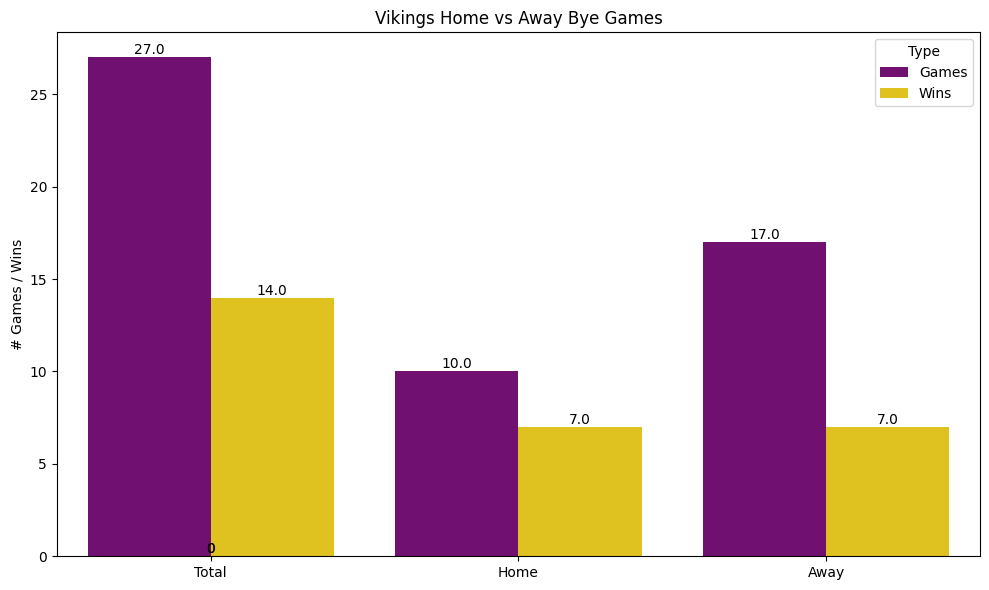

In [55]:
# Plot the HOme and away wins after the bye week
gameData = pd.DataFrame({
    'Category' : ["Total", "Total", "Home", "Home", "Away", "Away"],
    'Type' : ["Games", "Wins", "Games", "Wins", "Games", "Wins"],
    'Value': [len(postByeHomeGames) + len(postByeAwayGames),  # Total games played
              postByeWins + postByeAwayWins,                  # Total Games won
              len(postByeHomeGames),                          # Home Games played
              postByeWins,                                    # Home Games won
              len(postByeAwayGames),                          # Away Games played
              postByeAwayWins]                                # Away Games won
})
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Category', y='Value', data=gameData, hue='Type', palette=['purple', 'gold'], legend=True)

# Set the labels
plt.title("Vikings Home vs Away Bye Games")
plt.ylabel("# Games / Wins")
plt.xlabel("")

# If the differential is > 0, the bar is green, if < 0, the bar should be red
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height()}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [56]:
# Plot the HOme and away wins after the bye week, as winning percentages
gameData = pd.DataFrame({
    'Category' : ["All Bye Games", "Home Games", "Away Games"],
    'Value' : [winPercentage, postByeHomeWinPerecentage, postByeAwayWinPercentage]                          # Away Games won
})
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Category', y='Value', hue='Category', data=gameData, palette=['purple', 'gold'], legend=False)

# Set the labels
plt.title("Vikings Home vs Away Bye Games")
plt.ylabel("Winning Percentage")
plt.xlabel("")

# If the differential is > 0, the bar is green, if < 0, the bar should be red
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.2%}',
        ha='center',
        va='bottom'
    )

# Format the Y-axis to show percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Show the plot
plt.tight_layout()
plt.show()

NameError: name 'postByeHomeWinPerecentage' is not defined

In [ ]:
allPostByeGames = vikingsSchedule[vikingsSchedule['had_bye'] == True].copy()
allPostByeGames = allPostByeGames.sort_values(by='season')
allPostByeGames['cumulative_wins'] = allPostByeGames['vikings_win'].cumsum()

print(allPostByeGames[['season', 'week', 'vikings_win', 'cumulative_wins']])

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(allPostByeGames['season'], allPostByeGames['cumulative_wins'], marker="o")
# hint: x axis = season, y axis = cumulative_wins
# use plt.plot() instead of sns.barplot() for a line chart
# plt.plot(x, y, marker='o') draws the line with dots at each data point

plt.title("Vikings Cumulative Post-Bye Wins 1999-2024")
plt.xlabel("Season")
plt.ylabel("Cumulative Wins")

plt.show()